In [56]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns


# Load dataset
concerts = pl.read_parquet("../data/raw/concerts_raw.parquet")

# Inspect schema, row count, and missing values
print(f"Shape: {df.shape}")
print(df.schema)
print(df.null_count())

Shape: (1528, 11)
Schema({'id': String, 'name': String, 'city': String, 'state': String, 'venue': String, 'genre': String, 'sub_genre': String, 'event_date': String, 'min_price': Float64, 'max_price': Float64, 'currency': String})
shape: (1, 11)
┌─────┬──────┬──────┬───────┬───┬────────────┬───────────┬───────────┬──────────┐
│ id  ┆ name ┆ city ┆ state ┆ … ┆ event_date ┆ min_price ┆ max_price ┆ currency │
│ --- ┆ ---  ┆ ---  ┆ ---   ┆   ┆ ---        ┆ ---       ┆ ---       ┆ ---      │
│ u32 ┆ u32  ┆ u32  ┆ u32   ┆   ┆ u32        ┆ u32       ┆ u32       ┆ u32      │
╞═════╪══════╪══════╪═══════╪═══╪════════════╪═══════════╪═══════════╪══════════╡
│ 0   ┆ 0    ┆ 0    ┆ 0     ┆ … ┆ 0          ┆ 0         ┆ 0         ┆ 0        │
└─────┴──────┴──────┴───────┴───┴────────────┴───────────┴───────────┴──────────┘


In [10]:
concerts["min_price"].describe()

statistic,value
str,f64
"""count""",1528.0
"""null_count""",0.0
"""mean""",24.56305
"""std""",17.90958
"""min""",0.0
"""25%""",15.0
"""50%""",24.91
"""75%""",32.92
"""max""",235.0


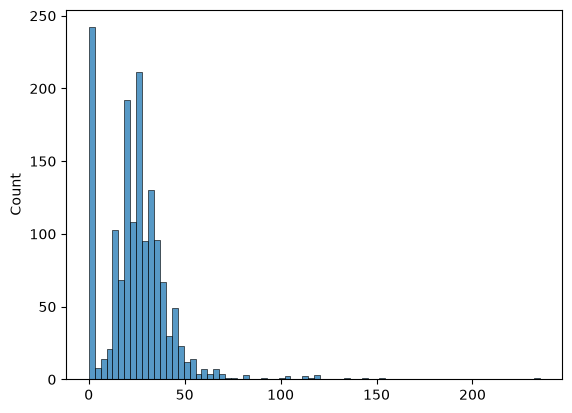

In [16]:
sns.histplot(concerts["min_price"].to_numpy())
plt.show() #checking to see the general shape

<Axes: ylabel='Count'>

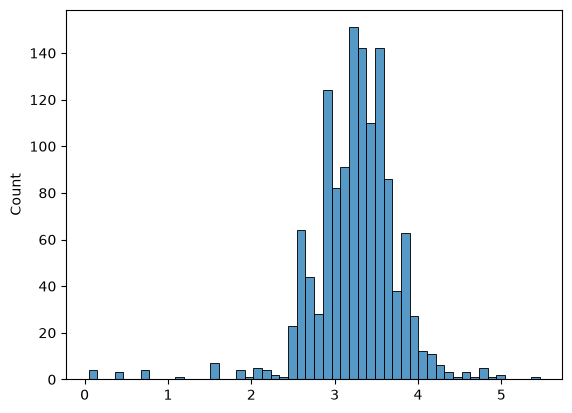

In [37]:
paid_concerts = concerts.filter(pl.col("min_price") > 0) #saw many 0 dollars that would mislead the regression
paid_concerts
sns.histplot((paid_concerts["min_price"].log().to_numpy())) #used log to get a standard distribution

In [39]:
paid_concerts.filter(pl.col("min_price") > 1).filter(pl.col("min_price") < 5) #checking to see if the outliers are flat admission fees

id,name,city,state,venue,genre,sub_genre,event_date,min_price,max_price,currency
str,str,str,str,str,str,str,str,f64,f64,str
"""rZ7HnEZ1AfGdo7""","""John Boerstler & Friends ft. S…","""Columbus""","""OH""","""Woodlands Tavern""","""Other""",null,"""2026-09-11""",1.5,1.5,"""USD"""
"""rZ7HnEZ1Afv3Jf""","""SMASH disco~glam~metal~punk-hi…","""Portland""","""OR""","""Dante's""","""Dance/Electronic""","""Dance Pop""","""2026-10-03""",1.05,1.05,"""USD"""
"""rZ7HnEZ1Af03_d""","""HOTWAX disco~glam~metal~punk~h…","""Portland""","""OR""","""Dante's""","""Dance/Electronic""","""Dance Pop""","""2026-10-02""",2.08,2.08,"""USD"""
"""rZ7HnEZ1Af03jS""","""HOTWAX disco~glam~metal~punk~h…","""Portland""","""OR""","""Dante's""","""Dance/Electronic""","""Dance Pop""","""2026-09-25""",2.08,2.08,"""USD"""
"""rZ7HnEZ1Af03jK""","""HOTWAX disco~glam~metal~punk~h…","""Portland""","""OR""","""Dante's""","""Dance/Electronic""","""Dance Pop""","""2026-09-18""",2.08,2.08,"""USD"""
…,…,…,…,…,…,…,…,…,…,…
"""rZ7HnEZ1A4ZwZS""","""Writers Night hosted by Steve …","""Nashville""","""TN""","""The Bluebird Cafe""","""Other""",null,"""2026-09-27""",4.86,4.86,"""USD"""
"""rZ7HnEZ1A4Zt4d""","""Americana Music Association Pr…","""Nashville""","""TN""","""The Bluebird Cafe""","""Country""","""Country""","""2026-09-17""",4.86,4.86,"""USD"""
"""rZ7HnEZ1Af03fK""","""HOTWAX disco~glam~metal~punk~h…","""Portland""","""OR""","""Dante's""","""Dance/Electronic""","""Dance Pop""","""2026-09-11""",2.08,2.08,"""USD"""


In [51]:
paid_concerts.filter(pl.col("min_price") >= 5).group_by("genre").agg([pl.len().alias("count"),pl.col("min_price").median().alias("median_price"),pl.col("min_price").mean().alias("mean_price")]).sort("count", descending=True) 
#checking to see if genre has a difference in price

genre,count,median_price,mean_price
str,u32,f64,f64
"""Alternative""",228,24.47,27.613684
"""Rock""",223,26.15,28.625919
"""Jazz""",168,35.65,36.560238
"""Other""",128,23.575,25.37625
"""Country""",97,25.16,25.654948
…,…,…,…
"""Blues""",22,23.0,23.98
"""Religious""",11,27.62,29.819091
"""Reggae""",8,28.455,28.04875


In [59]:
paid_concerts = paid_concerts.with_columns(pl.col("city").str.strip_chars()) #combined duplicate cities
paid_concerts.filter(pl.col("min_price") >= 5).group_by("city").agg([pl.len().alias("count"),pl.col("min_price").median().alias("median_price")]).sort("count", descending=True) #checking if cost of living in different cities affect cost


city,count,median_price
str,u32,f64
"""New Orleans""",139,27.98
"""Nashville""",124,25.72
"""New York""",117,35.46
"""Columbus""",94,25.89
"""Seattle""",93,25.49
…,…,…
"""Kansas City""",5,27.62
"""Austin""",3,28.61
"""Atlanta""",1,26.74


In [63]:
paid_concerts = paid_concerts.with_columns(pl.col("event_date").dt.weekday().alias("day_of_week"),pl.col("event_date").dt.month().alias("month")) #separated day of week and month (day of week goes from monday(1) - sunday(7))
paid_concerts

id,name,city,state,venue,genre,sub_genre,event_date,min_price,max_price,currency,day_of_week,month
str,str,str,str,str,str,str,date,f64,f64,str,i8,i8
"""rZ7HnEZ1Af1Z47""","""Society Of The Silver Cross To…","""Seattle""","""WA""","""Tractor""","""Rock""","""Alternative Rock""",2026-09-24,18.9,18.9,"""USD""",4,9
"""rZ7HnEZ1A4ZtoK""","""An Evening with Stephanie Urbi…","""Nashville""","""TN""","""The Bluebird Cafe""","""Country""","""Honky Tonk""",2026-09-15,27.63,27.63,"""USD""",2,9
"""rZ7HnEZ1A4ZNPd""","""Manic Outburst, Condition Crit…","""Detroit""","""MI""","""TSDMAAC""","""Metal""","""Thrash & Speed""",2026-09-10,21.36,21.36,"""USD""",4,9
"""rZ7HnEZ1AfFk-V""","""Cristina Vane w/ Kate Dinsmore…","""Seattle""","""WA""","""Tractor""","""Folk""","""Americana""",2026-09-19,25.08,31.26,"""USD""",6,9
"""rZ7HnEZ1Afkfff""","""YHWH Nailgun, Nudo""","""Detroit""","""MI""","""TSDMAAC (Catacombs)""","""Alternative""","""Alternative""",2026-09-19,32.92,32.92,"""USD""",6,9
…,…,…,…,…,…,…,…,…,…,…,…,…
"""rZ7HnEZ1A4ZJPS""","""Ben Musser | Sasha Dobson""","""New York""","""NY""","""Bowery Palace""","""Folk""","""Americana""",2026-09-09,18.78,18.78,"""USD""",3,9
"""rZ7HnEZ1Af13uf""","""Girl of Glass, Thus Spoke Zara…","""Detroit""","""MI""","""TSDMAAC""","""Metal""","""Heavy Metal""",2026-11-15,21.72,21.72,"""USD""",7,11
"""rZ7HnEZ1AfavjV""","""The Grammy Winning Hot 8 Brass…","""New Orleans""","""LA""","""Howlin' Wolf""","""Jazz""","""Jazz""",2026-10-25,24.94,24.94,"""USD""",7,10


In [66]:
weekend_shows = paid_concerts.with_columns(pl.col("day_of_week").is_in([5, 6, 7]).alias("is_weekend"))
weekend_shows.group_by("is_weekend").agg([pl.len().alias("count"),pl.col("min_price").median().alias("median_price")]) #checking if weekend influenced price (does not)

is_weekend,count,median_price
bool,u32,f64
false,581,26.46
true,716,26.78


In [67]:
weekday_shows = paid_concerts.with_columns(~pl.col("day_of_week").is_in([5, 6, 7]).alias("is_weekend"))

is_weekend,count,median_price
bool,u32,f64
false,716,26.78
true,581,26.46


In [ ]:
unpaid_concerts = concerts.filter(pl.col("min_price") == 0) #save this for later

In [69]:
paid_concerts.write_parquet("cleaned_concerts.parquet")